# Precipitation

Descarga el registro completo de precipitacion desde NOAA CDO para las estaciones seleccionadas, construye Thiessen recortado a NYC y segmenta eventos de lluvia por estacion.

Regla de eventos:
- separacion minima: `6 h` sin lluvia;
- umbral minimo del evento: `1.1 mm`;
- limpieza previa: valores negativos fuera.

Como el registro disponible para estas estaciones es diario, la separacion efectiva se adapta al intervalo observado para no fragmentar todos los eventos en bloques de un solo dia.

La ultima celda muestra como filtrar las estaciones que quieres analizar.


In [1]:
import hashlib
import os
import time
from datetime import date, timedelta
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from shapely import make_valid, voronoi_polygons
from shapely.ops import unary_union

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

plt.style.use('seaborn-v0_8-whitegrid')

def find_project_root() -> Path:
    # Locate the repository root from any notebook working directory.
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'data').exists():
            return candidate
    return current


ROOT = find_project_root()

INVENTORY_PATH = ROOT / 'data' / 'temporal' / 'noaa' / '4308211.csv'
SPATIAL_OUTPUT_DIR = ROOT / 'data' / 'spatial' / 'vector' / 'noaa'
TEMPORAL_OUTPUT_DIR = ROOT / 'data' / 'temporal' / 'noaa'
RAW_CACHE_DIR = TEMPORAL_OUTPUT_DIR / 'cache'
EVENT_DIR = TEMPORAL_OUTPUT_DIR / 'precip_events'
EVENT_SUMMARY_PATH = TEMPORAL_OUTPUT_DIR / 'precipitation_event_summary.csv'

for folder in (SPATIAL_OUTPUT_DIR, TEMPORAL_OUTPUT_DIR, RAW_CACHE_DIR, EVENT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

NOAA_BASE_URL = 'https://www.ncei.noaa.gov/cdo-web/api/v2/data'
NOAA_TOKEN_ENV_NAMES = ('NOAA_CDO_TOKEN', 'NOAA_API_TOKEN')
NOAA_DATASET_ID = 'GHCND'
NOAA_DATATYPE_ID = 'PRCP'
NOAA_START_DATE = '2010-01-01'
NOAA_END_DATE = date.today().isoformat()
NOAA_LIMIT = 1000
NOAA_MAX_RETRIES = 5
NOAA_RETRY_BACKOFF_SECONDS = 2.0

EVENT_GAP = pd.Timedelta(hours=6)
MIN_EVENT_MM = 1.1


In [2]:
def load_nyc_boundary():
    # Load the NYC borough polygons and a valid union geometry.
    nyc = gpd.read_file(ROOT / 'data' / 'spatial' / 'vector' / 'nyc_borough_boundary' / 'nybb.geojson')
    nyc = nyc.copy()
    nyc['geometry'] = nyc.geometry.apply(make_valid)
    city = unary_union(nyc.geometry)
    return nyc, city


def build_thiessen(points_gdf, clip_geom):
    # Build Thiessen polygons, clipped to the NYC union geometry.
    if len(points_gdf) < 2:
        raise ValueError('Se necesitan al menos dos estaciones para construir Thiessen.')
    diagram = voronoi_polygons(
        unary_union(points_gdf.geometry),
        extend_to=clip_geom,
        ordered=True,
    )
    rows = []
    base_rows = points_gdf.drop(columns='geometry').to_dict('records')
    for record, cell in zip(base_rows, diagram.geoms):
        clipped = cell.intersection(clip_geom)
        if clipped.is_empty:
            continue
        record = dict(record)
        record['geometry'] = clipped
        rows.append(record)
    return gpd.GeoDataFrame(rows, crs=points_gdf.crs)


def load_station_inventory():
    # Load the station catalog with coordinates and NOAA ids.
    inventory = pd.read_csv(
        INVENTORY_PATH,
        usecols=['STATION', 'NAME', 'LATITUDE', 'LONGITUDE'],
        dtype={'STATION': 'string', 'NAME': 'string'},
    ).drop_duplicates('STATION')
    inventory = inventory.rename(
        columns={
            'STATION': 'station_code',
            'NAME': 'station_name',
            'LATITUDE': 'lat',
            'LONGITUDE': 'lon',
        }
    )
    inventory['station_id'] = 'GHCND:' + inventory['station_code'].astype(str)
    inventory['role'] = 'inventory'
    return inventory.sort_values('station_id').reset_index(drop=True)


def infer_observation_step(timestamps):
    # Infer the sampling interval from the observed timestamps.
    clean = pd.Series(pd.to_datetime(timestamps, errors='coerce')).dropna().sort_values().drop_duplicates()
    if len(clean) < 2:
        return pd.Timedelta(days=1)
    diffs = clean.diff().dropna()
    diffs = diffs[diffs > pd.Timedelta(0)]
    if diffs.empty:
        return pd.Timedelta(days=1)
    mode = diffs.mode()
    if not mode.empty:
        return mode.iloc[0]
    return diffs.median()


def precip_cache_path(station_ids, dataset_id=NOAA_DATASET_ID, datatype_id=NOAA_DATATYPE_ID,
                      start_date=NOAA_START_DATE, end_date=NOAA_END_DATE):
    # Build a stable cache path for a station selection and date range.
    clean_ids = [str(station_id) for station_id in station_ids if pd.notna(station_id)]
    clean_ids = sorted(set(clean_ids))
    if not clean_ids:
        raise ValueError('No hay estaciones seleccionadas para la descarga NOAA.')
    selection_key = '|'.join(clean_ids)
    selection_hash = hashlib.sha1(selection_key.encode('utf-8')).hexdigest()[:12]
    name = f'noaa_precip_raw_{dataset_id}_{datatype_id}_{start_date}_{end_date}_{selection_hash}.csv'
    return RAW_CACHE_DIR / name


def normalize_precip_frame(frame):
    # Normalize NOAA precipitation records to the notebook schema.
    out = frame.copy()
    rename_map = {}
    if 'date' in out.columns and 'timestamp' not in out.columns:
        rename_map['date'] = 'timestamp'
    if 'station' in out.columns and 'station_id' not in out.columns:
        rename_map['station'] = 'station_id'
    if 'value' in out.columns and 'precip_mm' not in out.columns:
        rename_map['value'] = 'precip_mm'
    out = out.rename(columns=rename_map)

    required = {'timestamp', 'station_id', 'precip_mm'}
    missing = required - set(out.columns)
    if missing:
        raise ValueError(f'La descarga NOAA no tiene las columnas esperadas: {sorted(missing)}')

    out['timestamp'] = pd.to_datetime(out['timestamp'], errors='coerce')
    out['station_id'] = out['station_id'].astype('string')
    out['precip_mm'] = pd.to_numeric(out['precip_mm'], errors='coerce')
    out = out.dropna(subset=['timestamp', 'station_id', 'precip_mm'])
    out = out.loc[out['precip_mm'] >= 0].copy()
    out = out.sort_values(['station_id', 'timestamp']).reset_index(drop=True)
    out['source_kind'] = 'noaa_cdo_api'
    return out


def fetch_noaa_data(
    token: str,
    dataset_id: str,
    datatype_id: str,
    start_date: str,
    end_date: str,
    stations: list[str],
    limit: int,
    max_retries: int,
    retry_backoff_seconds: float,
) -> pd.DataFrame:
    # Fetch NOAA CDO data in windows so long station histories remain manageable.
    headers = {'token': token}
    rows = []
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)
    window_start = start_ts

    while window_start <= end_ts:
        window_end = min(window_start + timedelta(days=364), end_ts)
        offset = 1

        while True:
            params = {
                'datasetid': dataset_id,
                'datatypeid': datatype_id,
                'startdate': window_start.strftime('%Y-%m-%d'),
                'enddate': window_end.strftime('%Y-%m-%d'),
                'limit': limit,
                'offset': offset,
                'units': 'metric',
            }
            for station in stations:
                params.setdefault('stationid', [])
                params['stationid'].append(station)

            response = None
            for attempt in range(max_retries + 1):
                response = requests.get(
                    NOAA_BASE_URL,
                    headers=headers,
                    params=params,
                    timeout=60,
                )
                if response.status_code not in {429, 500, 502, 503, 504}:
                    break
                if attempt == max_retries:
                    break
                wait_seconds = retry_backoff_seconds * (2 ** attempt)
                print(
                    '[retry] NOAA request failed '
                    f"status={response.status_code} "
                    f"window={params['startdate']}..{params['enddate']} "
                    f'offset={offset} '
                    f'attempt={attempt + 1}/{max_retries + 1} '
                    f'sleep={wait_seconds:.1f}s'
                )
                time.sleep(wait_seconds)

            response.raise_for_status()
            payload = response.json()
            batch = payload.get('results', [])
            if not batch:
                break

            rows.extend(batch)
            offset += limit
            if len(batch) < limit:
                break

        window_start = window_end + timedelta(days=1)

    return pd.DataFrame.from_records(rows)


def load_or_fetch_precip(station_ids, force_refresh=False):
    # Load a cached NOAA precipitation extract or fetch it from the API.
    cache_path = precip_cache_path(station_ids)
    if cache_path.exists() and not force_refresh:
        frame = pd.read_csv(cache_path, low_memory=False)
        return normalize_precip_frame(frame)

    token = next((os.getenv(name) for name in NOAA_TOKEN_ENV_NAMES if os.getenv(name)), None)
    if not token:
        raise RuntimeError(
            'Falta el token de NOAA. Define NOAA_CDO_TOKEN o NOAA_API_TOKEN para descargar el registro completo.'
        )

    raw = fetch_noaa_data(
        token=token,
        dataset_id=NOAA_DATASET_ID,
        datatype_id=NOAA_DATATYPE_ID,
        start_date=NOAA_START_DATE,
        end_date=NOAA_END_DATE,
        stations=[str(station_id) for station_id in station_ids],
        limit=NOAA_LIMIT,
        max_retries=NOAA_MAX_RETRIES,
        retry_backoff_seconds=NOAA_RETRY_BACKOFF_SECONDS,
    )
    frame = normalize_precip_frame(raw)
    frame.to_csv(cache_path, index=False)
    return frame


def set_map_extent(ax, geom, pad=0.03):
    # Set a small padded view around a geometry.
    minx, miny, maxx, maxy = geom.bounds
    dx = (maxx - minx) * pad
    dy = (maxy - miny) * pad
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)


def split_rain_events(station_frame, station_id, station_name, gap=EVENT_GAP, min_total=MIN_EVENT_MM):
    # Split one station series into independent rain events and write a CSV per event.
    frame = station_frame.copy().sort_values('timestamp').reset_index(drop=True)
    frame = frame.dropna(subset=['timestamp', 'precip_mm'])
    frame = frame.loc[frame['precip_mm'] >= 0].copy()

    if frame.empty:
        return pd.DataFrame(
            columns=[
                'station_id', 'station_name', 'event_id', 'event_uid', 'start', 'end',
                'duration_hours', 'precip_mm', 'mean_intensity_mm_per_hr', 'n_records',
                'wet_records', 'csv_path',
            ]
        )

    sample_step = infer_observation_step(frame['timestamp'])
    effective_gap = max(gap, sample_step * 1.5)

    wet = frame.loc[frame['precip_mm'] > 0, ['timestamp', 'precip_mm']].copy()
    if wet.empty:
        return pd.DataFrame(
            columns=[
                'station_id', 'station_name', 'event_id', 'event_uid', 'start', 'end',
                'duration_hours', 'precip_mm', 'mean_intensity_mm_per_hr', 'n_records',
                'wet_records', 'csv_path',
            ]
        )

    wet['time_diff'] = wet['timestamp'].diff()
    wet['is_new_event'] = wet['time_diff'].isna() | (wet['time_diff'] > effective_gap)
    wet['event_id'] = wet['is_new_event'].cumsum().astype(int)

    summaries = []
    station_slug = str(station_id).replace(':', '_')
    station_dir = EVENT_DIR / station_slug
    station_dir.mkdir(parents=True, exist_ok=True)

    for event_id, wet_group in wet.groupby('event_id', sort=True):
        wet_group = wet_group.sort_values('timestamp')
        start = wet_group['timestamp'].min()
        end = wet_group['timestamp'].max()
        event_frame = frame.loc[(frame['timestamp'] >= start) & (frame['timestamp'] <= end)].copy()
        if event_frame.empty:
            continue

        total_mm = float(event_frame['precip_mm'].sum())
        if total_mm < min_total:
            continue

        duration_hours = float(max(((end - start) + sample_step).total_seconds() / 3600.0, sample_step.total_seconds() / 3600.0))
        intensity = total_mm / duration_hours if duration_hours > 0 else np.nan
        event_uid = f'{station_slug}_{int(event_id):04d}'
        event_path = station_dir / f'event_{int(event_id):04d}.csv'

        event_frame = event_frame.assign(
            event_id=int(event_id),
            event_uid=event_uid,
            station_id=station_id,
            station_name=station_name,
        )
        event_frame.to_csv(event_path, index=False)

        summaries.append(
            {
                'station_id': station_id,
                'station_name': station_name,
                'event_id': int(event_id),
                'event_uid': event_uid,
                'start': start,
                'end': end,
                'duration_hours': duration_hours,
                'precip_mm': total_mm,
                'mean_intensity_mm_per_hr': intensity,
                'n_records': int(len(event_frame)),
                'wet_records': int(len(wet_group)),
                'csv_path': str(event_path),
            }
        )

    return pd.DataFrame(summaries)


In [3]:
nyc_boroughs, nyc_union = load_nyc_boundary()
station_catalog = load_station_inventory()

seed_points = gpd.GeoDataFrame(
    station_catalog,
    geometry=gpd.points_from_xy(station_catalog['lon'], station_catalog['lat']),
    crs='EPSG:4326',
)
seed_thiessen = build_thiessen(seed_points, nyc_union)

city_station_ids = set(seed_thiessen['station_id'].astype(str))
city_stations = station_catalog[station_catalog['station_id'].isin(city_station_ids)].copy().sort_values('station_id').reset_index(drop=True)
if city_stations.empty:
    raise ValueError('No se encontraron estaciones de precipitación dentro de NYC.')

# Edita esta lista antes de correr la descarga si quieres un subconjunto.
wanted_station_ids = []
if wanted_station_ids:
    analysis_stations = city_stations.loc[city_stations['station_id'].isin(wanted_station_ids)].copy()
else:
    analysis_stations = city_stations.copy()
analysis_stations = analysis_stations.sort_values('station_id').reset_index(drop=True)
analysis_points = gpd.GeoDataFrame(
    analysis_stations,
    geometry=gpd.points_from_xy(analysis_stations['lon'], analysis_stations['lat']),
    crs='EPSG:4326',
)

raw_precip = load_or_fetch_precip(analysis_stations['station_id'].tolist())
raw_precip = raw_precip.merge(
    analysis_stations[['station_id', 'station_name', 'lat', 'lon']],
    on='station_id',
    how='left',
)

print(f'Estaciones del catalogo: {len(station_catalog):,}')
print(f'Estaciones que intersectan NYC: {len(city_stations):,}')
print(f'Estaciones seleccionadas para el analisis: {len(analysis_stations):,}')
print(f'Registros NOAA descargados: {len(raw_precip):,}')
raw_precip.head()


[retry] NOAA request failed status=429 window=2011-01-01..2011-12-31 offset=2001 attempt=1/6 sleep=2.0s
[retry] NOAA request failed status=429 window=2013-12-31..2014-12-30 offset=1 attempt=1/6 sleep=2.0s
[retry] NOAA request failed status=429 window=2017-12-30..2018-12-29 offset=1 attempt=1/6 sleep=2.0s
[retry] NOAA request failed status=429 window=2019-12-30..2020-12-28 offset=1 attempt=1/6 sleep=2.0s
[retry] NOAA request failed status=429 window=2023-12-29..2024-12-27 offset=1 attempt=1/6 sleep=2.0s
Estaciones del catalogo: 108
Estaciones que intersectan NYC: 14
Estaciones seleccionadas para el analisis: 14
Registros NOAA descargados: 36,134


,timestamp,datatype,station_id,attributes,precip_mm,source_kind,station_name,lat,lon
0,2010-01-01,PRCP,GHCND:US1NJMN0010,",,N,0730",7.9,noaa_cdo_api,"EATONTOWN 1.2 NE, NJ US",40.3034,-74.040017
1,2010-01-02,PRCP,GHCND:US1NJMN0010,",,N,0745",0.0,noaa_cdo_api,"EATONTOWN 1.2 NE, NJ US",40.3034,-74.040017
2,2010-01-03,PRCP,GHCND:US1NJMN0010,",,N,0730",0.0,noaa_cdo_api,"EATONTOWN 1.2 NE, NJ US",40.3034,-74.040017
3,2010-01-04,PRCP,GHCND:US1NJMN0010,"T,,N,0610",0.0,noaa_cdo_api,"EATONTOWN 1.2 NE, NJ US",40.3034,-74.040017
4,2010-01-05,PRCP,GHCND:US1NJMN0010,",,N,0700",0.0,noaa_cdo_api,"EATONTOWN 1.2 NE, NJ US",40.3034,-74.040017


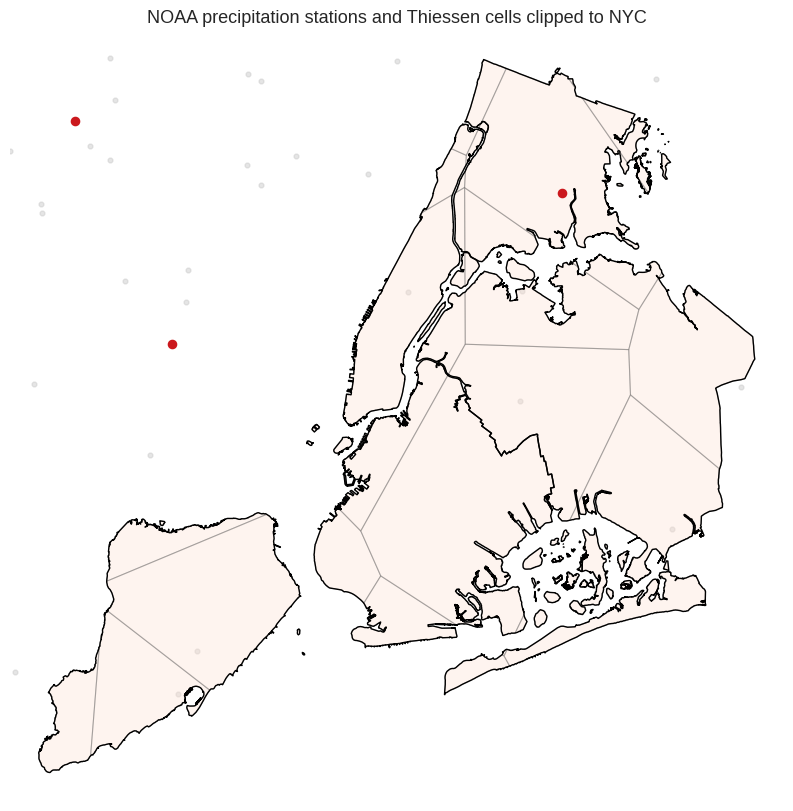

,station_id,station_name,geometry
0,GHCND:US1NJMN0010,"EATONTOWN 1.2 NE, NJ US","POLYGON ((-74.21528 40.50593, -74.21538 40.505..."
1,GHCND:US1NJMS0049,"FLORHAM PARK 0.2 WNW, NJ US","MULTIPOLYGON (((-74.20277 40.60865, -74.20274 ..."
2,GHCND:US1NJPS0012,"LITTLE FALLS TWP 0.5 WNW, NJ US","POLYGON ((-74.20854 40.56999, -74.20847 40.570..."
3,GHCND:US1NJPS0019,"WANAQUE 0.6 S, NJ US","MULTIPOLYGON (((-74.07867 40.64799, -74.07709 ..."
4,GHCND:US1NYWC0005,"HARRISON 4.1 SSW, NY US","MULTIPOLYGON (((-73.99018 40.61178, -73.93188 ..."
5,GHCND:USC00066655,"PUTNAM LAKE, CT US","MULTIPOLYGON (((-73.92377 40.85914, -73.9242 4..."
6,GHCND:USC00283704,"HARRISON, NJ US","MULTIPOLYGON (((-73.91405 40.87518, -73.91408 ..."
7,GHCND:USC00285503,"MIDLAND PARK, NJ US","MULTIPOLYGON (((-73.9344 40.83612, -73.93445 4..."
8,GHCND:USC00287079,"PLAINFIELD, NJ US","MULTIPOLYGON (((-74.00567 40.63819, -73.93812 ..."
9,GHCND:USC00287865,"SANDY HOOK, NJ US","MULTIPOLYGON (((-73.92476 40.77872, -73.92424 ..."


In [4]:
# Mapa: red seed, red activa para NYC y estaciones seleccionadas.
fig, ax = plt.subplots(figsize=(10, 10))
nyc_boroughs.boundary.plot(ax=ax, color='black', linewidth=1)
seed_points.plot(ax=ax, color='0.78', markersize=12, alpha=0.45)
seed_thiessen.plot(ax=ax, color='#fee0d2', alpha=0.35, edgecolor='0.35', linewidth=0.8)
analysis_points.plot(ax=ax, color='#cb181d', markersize=35)
set_map_extent(ax, nyc_union, pad=0.04)
ax.set_title('NOAA precipitation stations and Thiessen cells clipped to NYC', fontsize=13)
ax.set_axis_off()
plt.show()

seed_thiessen[['station_id', 'station_name', 'geometry']]


In [5]:
# Guardar capas espaciales.
seed_points_out = SPATIAL_OUTPUT_DIR / 'precipitation_seed_stations.geojson'
city_points_out = SPATIAL_OUTPUT_DIR / 'precipitation_city_stations.geojson'
analysis_points_out = SPATIAL_OUTPUT_DIR / 'precipitation_selected_stations.geojson'
thiessen_out = SPATIAL_OUTPUT_DIR / 'precipitation_thiessen.geojson'

seed_points.to_file(seed_points_out, driver='GeoJSON')
city_points = gpd.GeoDataFrame(
    city_stations,
    geometry=gpd.points_from_xy(city_stations['lon'], city_stations['lat']),
    crs='EPSG:4326',
)
city_points.to_file(city_points_out, driver='GeoJSON')
analysis_points.to_file(analysis_points_out, driver='GeoJSON')
seed_thiessen.to_file(thiessen_out, driver='GeoJSON')

print(seed_points_out)
print(city_points_out)
print(analysis_points_out)
print(thiessen_out)


/home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_seed_stations.geojson
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_city_stations.geojson
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_selected_stations.geojson
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_thiessen.geojson


In [6]:
# Segmentacion de eventos por estacion y exportacion de CSV por evento.
stations_for_events = analysis_stations.copy()
if stations_for_events.empty:
    raise ValueError('No hay estaciones seleccionadas para segmentar eventos.')

event_tables = []
for row in stations_for_events.to_dict('records'):
    station_id = row['station_id']
    station_name = row['station_name']
    series = raw_precip.loc[raw_precip['station_id'] == station_id].copy()
    if series.empty:
        continue
    event_table = split_rain_events(series, station_id, station_name)
    if not event_table.empty:
        event_tables.append(event_table)

event_summary = pd.concat(event_tables, ignore_index=True) if event_tables else pd.DataFrame(
    columns=[
        'station_id', 'station_name', 'event_id', 'event_uid', 'start', 'end',
        'duration_hours', 'precip_mm', 'mean_intensity_mm_per_hr', 'n_records', 'wet_records', 'csv_path',
    ]
)
event_summary = event_summary.sort_values(['station_id', 'start', 'event_id'], kind='stable').reset_index(drop=True)
event_summary.to_csv(EVENT_SUMMARY_PATH, index=False)
event_summary


,station_id,station_name,event_id,event_uid,start,end,duration_hours,precip_mm,mean_intensity_mm_per_hr,n_records,wet_records,csv_path
0,GHCND:US1NJMN0010,"EATONTOWN 1.2 NE, NJ US",1,GHCND_US1NJMN0010_0001,2010-01-01,2010-01-01,24.0,7.9,0.329167,1,1,/home/map10194/Documents/urban-flood-stress/da...
1,GHCND:US1NJMN0010,"EATONTOWN 1.2 NE, NJ US",3,GHCND_US1NJMN0010_0003,2010-01-18,2010-01-18,24.0,26.7,1.112500,1,1,/home/map10194/Documents/urban-flood-stress/da...
2,GHCND:US1NJMN0010,"EATONTOWN 1.2 NE, NJ US",4,GHCND_US1NJMN0010_0004,2010-01-26,2010-01-26,24.0,38.6,1.608333,1,1,/home/map10194/Documents/urban-flood-stress/da...
3,GHCND:US1NJMN0010,"EATONTOWN 1.2 NE, NJ US",6,GHCND_US1NJMN0010_0006,2010-02-03,2010-02-03,24.0,3.6,0.150000,1,1,/home/map10194/Documents/urban-flood-stress/da...
4,GHCND:US1NJMN0010,"EATONTOWN 1.2 NE, NJ US",7,GHCND_US1NJMN0010_0007,2010-02-10,2010-02-10,24.0,20.3,0.845833,1,1,/home/map10194/Documents/urban-flood-stress/da...
...,...,...,...,...,...,...,...,...,...,...,...,...
5887,GHCND:USC00302129,"DOBBS FERRY ARDSLEY, NY US",117,GHCND_USC00302129_0117,2012-06-07,2012-06-07,24.0,2.0,0.083333,1,1,/home/map10194/Documents/urban-flood-stress/da...
5888,GHCND:USC00302129,"DOBBS FERRY ARDSLEY, NY US",118,GHCND_USC00302129_0118,2012-06-09,2012-06-13,120.0,31.3,0.260833,5,5,/home/map10194/Documents/urban-flood-stress/da...
5889,GHCND:USC00302129,"DOBBS FERRY ARDSLEY, NY US",119,GHCND_USC00302129_0119,2012-06-22,2012-06-23,48.0,21.6,0.450000,2,2,/home/map10194/Documents/urban-flood-stress/da...
5890,GHCND:USC00302129,"DOBBS FERRY ARDSLEY, NY US",120,GHCND_USC00302129_0120,2012-06-25,2012-06-26,48.0,18.8,0.391667,2,2,/home/map10194/Documents/urban-flood-stress/da...


In [7]:
# Resumen rapido.
print(f'Eventos detectados: {len(event_summary):,}')
display(
    event_summary.groupby('station_id', dropna=False)
    .agg(
        events=('event_id', 'size'),
        total_mm=('precip_mm', 'sum'),
        mean_intensity_mm_per_hr=('mean_intensity_mm_per_hr', 'mean'),
        max_mm=('precip_mm', 'max'),
        median_duration_hours=('duration_hours', 'median'),
        max_records=('n_records', 'max'),
    )
    .sort_values('events', ascending=False)
)

display(
    event_summary[['duration_hours', 'precip_mm', 'mean_intensity_mm_per_hr', 'n_records', 'wet_records']]
    .describe()
)

print(f'Eventos con mas de un registro: {(event_summary["n_records"] > 1).sum():,}')
print(f'Eventos con duracion positiva: {(event_summary["duration_hours"] > 0).sum():,}')


Eventos detectados: 5,892


,events,total_mm,mean_intensity_mm_per_hr,max_mm,median_duration_hours,max_records
station_id,,,,,,
GHCND:US1NJPS0012,987,22518.6,0.470040,249.4,48.0,10
GHCND:USC00283704,961,21915.6,0.504654,232.1,48.0,10
GHCND:USC00289187,909,19024.6,0.436990,177.6,48.0,10
GHCND:US1NJMN0010,885,19008.3,0.478428,200.7,48.0,9
GHCND:USC00066655,782,16451.4,0.505946,202.2,24.0,9
GHCND:US1NJMS0049,525,10737.5,0.407754,120.9,48.0,13
GHCND:US1NJPS0019,202,4699.8,0.512700,198.7,48.0,10
GHCND:USC00300961,190,4151.0,0.441920,151.4,48.0,6
GHCND:USC00287865,133,3096.4,0.774864,147.3,24.0,4


,duration_hours,precip_mm,mean_intensity_mm_per_hr,n_records,wet_records
count,5892.000000,5892.000000,5892.000000,5892.000000,5892.000000
mean,46.912424,21.885031,0.486067,1.954684,1.954684
std,29.140645,24.458942,0.514027,1.214194,1.214194
min,24.000000,1.100000,0.022222,1.000000,1.000000
25%,24.000000,5.300000,0.150000,1.000000,1.000000
50%,48.000000,14.200000,0.332639,2.000000,2.000000
75%,48.000000,29.200000,0.645833,2.000000,2.000000
max,312.000000,249.400000,8.425000,13.000000,13.000000


Eventos con mas de un registro: 3,231
Eventos con duracion positiva: 5,892


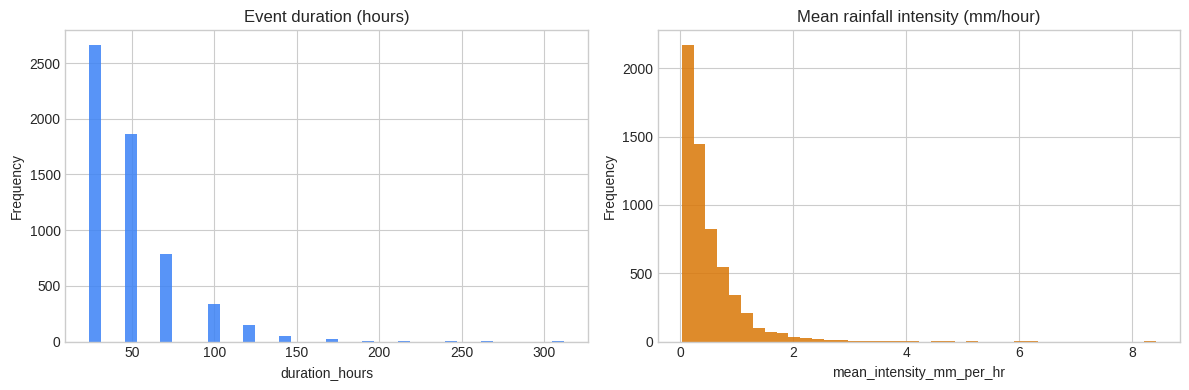

,station_id,event_id,start,end,duration_hours,precip_mm,mean_intensity_mm_per_hr,n_records
0,GHCND:US1NJMN0010,1,2010-01-01,2010-01-01,24.0,7.9,0.329167,1
1,GHCND:US1NJMN0010,3,2010-01-18,2010-01-18,24.0,26.7,1.112500,1
2,GHCND:US1NJMN0010,4,2010-01-26,2010-01-26,24.0,38.6,1.608333,1
3,GHCND:US1NJMN0010,6,2010-02-03,2010-02-03,24.0,3.6,0.150000,1
4,GHCND:US1NJMN0010,7,2010-02-10,2010-02-10,24.0,20.3,0.845833,1
5,GHCND:US1NJMN0010,8,2010-02-23,2010-02-27,120.0,95.6,0.796667,5
6,GHCND:US1NJMN0010,10,2010-03-13,2010-03-16,96.0,103.7,1.080208,4
7,GHCND:US1NJMN0010,11,2010-03-23,2010-03-23,24.0,24.6,1.025000,1
8,GHCND:US1NJMN0010,12,2010-03-26,2010-03-26,24.0,1.8,0.075000,1
9,GHCND:US1NJMN0010,13,2010-03-29,2010-03-31,72.0,121.2,1.683333,3


In [8]:
# Distribuciones de duracion e intensidad.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
event_summary['duration_hours'].plot.hist(bins=40, ax=axes[0], color='#3B82F6', alpha=0.85)
axes[0].set_title('Event duration (hours)')
axes[0].set_xlabel('duration_hours')

event_summary['mean_intensity_mm_per_hr'].plot.hist(bins=40, ax=axes[1], color='#D97706', alpha=0.85)
axes[1].set_title('Mean rainfall intensity (mm/hour)')
axes[1].set_xlabel('mean_intensity_mm_per_hr')

plt.tight_layout()
plt.show()

display(
    event_summary[['station_id', 'event_id', 'start', 'end', 'duration_hours', 'precip_mm', 'mean_intensity_mm_per_hr', 'n_records']]
    .head(10)
)


In [9]:
# Estaciones con mas eventos.
station_rank = (
    event_summary.groupby(['station_id', 'station_name'], dropna=False)
    .agg(
        events=('event_id', 'size'),
        total_mm=('precip_mm', 'sum'),
        mean_duration_hours=('duration_hours', 'mean'),
        mean_intensity_mm_per_hr=('mean_intensity_mm_per_hr', 'mean'),
    )
    .reset_index()
    .sort_values(['events', 'total_mm'], ascending=[False, False])
)
display(station_rank)


,station_id,station_name,events,total_mm,mean_duration_hours,mean_intensity_mm_per_hr
2,GHCND:US1NJPS0012,"LITTLE FALLS TWP 0.5 WNW, NJ US",987,22518.6,49.531915,0.470040
5,GHCND:USC00283704,"HARRISON, NJ US",961,21915.6,46.401665,0.504654
9,GHCND:USC00289187,"WANAQUE RAYMOND DAM, NJ US",909,19024.6,49.056106,0.436990
0,GHCND:US1NJMN0010,"EATONTOWN 1.2 NE, NJ US",885,19008.3,47.050847,0.478428
4,GHCND:USC00066655,"PUTNAM LAKE, CT US",782,16451.4,43.611253,0.505946
1,GHCND:US1NJMS0049,"FLORHAM PARK 0.2 WNW, NJ US",525,10737.5,52.891429,0.407754
3,GHCND:US1NJPS0019,"WANAQUE 0.6 S, NJ US",202,4699.8,47.643564,0.512700
10,GHCND:USC00300961,"BRONX, NY US",190,4151.0,48.252632,0.441920
8,GHCND:USC00287865,"SANDY HOOK, NJ US",133,3096.4,30.676692,0.774864
6,GHCND:USC00285503,"MIDLAND PARK, NJ US",121,2359.9,32.330579,0.604465


In [10]:
# Filtro manual de estaciones.
# Edita wanted_station_ids para quedarte solo con las estaciones que quieres estudiar.
# Si cambias esta lista, vuelve a ejecutar la celda de descarga NOAA y la segmentacion de eventos.
wanted_station_ids = [
    # 'GHCND:USW00014732',
    # 'GHCND:USW00094728',
]

if wanted_station_ids:
    analysis_stations = city_stations.loc[city_stations['station_id'].isin(wanted_station_ids)].copy()
else:
    analysis_stations = city_stations.copy()
analysis_stations = analysis_stations.sort_values('station_id').reset_index(drop=True)
analysis_points = gpd.GeoDataFrame(
    analysis_stations,
    geometry=gpd.points_from_xy(analysis_stations['lon'], analysis_stations['lat']),
    crs='EPSG:4326',
)

print(f'Estaciones candidatas en NYC: {len(city_stations):,}')
print(f'Estaciones seleccionadas para el analisis: {len(analysis_stations):,}')
display(analysis_stations[['station_id', 'station_name', 'lat', 'lon']])


Estaciones candidatas en NYC: 14
Estaciones seleccionadas para el analisis: 14


,station_id,station_name,lat,lon
0,GHCND:US1NJMN0010,"EATONTOWN 1.2 NE, NJ US",40.303400,-74.040017
1,GHCND:US1NJMS0049,"FLORHAM PARK 0.2 WNW, NJ US",40.777970,-74.399200
2,GHCND:US1NJPS0012,"LITTLE FALLS TWP 0.5 WNW, NJ US",40.879633,-74.227041
3,GHCND:US1NJPS0019,"WANAQUE 0.6 S, NJ US",41.035077,-74.289165
4,GHCND:US1NYWC0005,"HARRISON 4.1 SSW, NY US",40.963890,-73.723179
5,GHCND:USC00066655,"PUTNAM LAKE, CT US",41.082500,-73.638600
6,GHCND:USC00283704,"HARRISON, NJ US",40.748100,-74.152000
7,GHCND:USC00285503,"MIDLAND PARK, NJ US",40.993900,-74.145300
8,GHCND:USC00287079,"PLAINFIELD, NJ US",40.603600,-74.402500
9,GHCND:USC00287865,"SANDY HOOK, NJ US",40.463300,-74.005500


In [11]:
# Filtro manual de estaciones.
# Edita wanted_station_ids para quedarte solo con las estaciones que quieres estudiar.
# Si cambias esta lista, vuelve a ejecutar la celda de descarga NOAA y la segmentacion de eventos.
wanted_station_ids = [
    # 'GHCND:USW00014732',
    # 'GHCND:USW00094728',
]

if wanted_station_ids:
    analysis_stations = city_stations.loc[city_stations['station_id'].isin(wanted_station_ids)].copy()
else:
    analysis_stations = city_stations.copy()
analysis_stations = analysis_stations.sort_values('station_id').reset_index(drop=True)
analysis_points = gpd.GeoDataFrame(
    analysis_stations,
    geometry=gpd.points_from_xy(analysis_stations['lon'], analysis_stations['lat']),
    crs='EPSG:4326',
)

print(f'Estaciones candidatas en NYC: {len(city_stations):,}')
print(f'Estaciones seleccionadas para el analisis: {len(analysis_stations):,}')
display(analysis_stations[['station_id', 'station_name', 'lat', 'lon']])


Estaciones candidatas en NYC: 14
Estaciones seleccionadas para el analisis: 14


,station_id,station_name,lat,lon
0,GHCND:US1NJMN0010,"EATONTOWN 1.2 NE, NJ US",40.303400,-74.040017
1,GHCND:US1NJMS0049,"FLORHAM PARK 0.2 WNW, NJ US",40.777970,-74.399200
2,GHCND:US1NJPS0012,"LITTLE FALLS TWP 0.5 WNW, NJ US",40.879633,-74.227041
3,GHCND:US1NJPS0019,"WANAQUE 0.6 S, NJ US",41.035077,-74.289165
4,GHCND:US1NYWC0005,"HARRISON 4.1 SSW, NY US",40.963890,-73.723179
5,GHCND:USC00066655,"PUTNAM LAKE, CT US",41.082500,-73.638600
6,GHCND:USC00283704,"HARRISON, NJ US",40.748100,-74.152000
7,GHCND:USC00285503,"MIDLAND PARK, NJ US",40.993900,-74.145300
8,GHCND:USC00287079,"PLAINFIELD, NJ US",40.603600,-74.402500
9,GHCND:USC00287865,"SANDY HOOK, NJ US",40.463300,-74.005500
